In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score
import seaborn as sbn
import random

In [78]:
random.seed(42)

In [79]:
def train_and_eval(data, labels):
    x_train, x_val, y_train, y_val = train_test_split(data,labels, random_state=42)
    clf = SVC()
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_val)
    print("\tPrecision: %1.3f" % precision_score(y_val, y_pred))
    print("\tRecall: %1.3f" % recall_score(y_val, y_pred))
    return clf

In [80]:
def train_and_eval_rf(data, labels):
    x_train, x_val, y_train, y_val = train_test_split(data,labels, random_state=42)
    clf = RandomForestClassifier()
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_val)
    print("\tPrecision: %1.3f" % precision_score(y_val, y_pred))
    print("\tRecall: %1.3f" % recall_score(y_val, y_pred))
    return clf

In [81]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
g = df.groupby('y')
# On ré-equilibre le jeu de donnée pour que l'on ait pas de soucis dans le reste du tp du au desequilibre
df = g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)).reset_index(drop=True)
df.head(10) # affiche les 10 premières lignes

C:\Users\benoi\AppData\Local\Temp\ipykernel_34152\3661303928.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)).reset_index(drop=True)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,36,admin.,single,university.degree,no,yes,no,cellular,may,wed,...,3,999,0,nonexistent,-1.8,92.893,-46.2,1.281,5099.1,no
1,41,technician,single,professional.course,unknown,no,yes,cellular,aug,tue,...,3,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no
2,35,technician,single,university.degree,no,no,no,telephone,jun,tue,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
3,42,blue-collar,divorced,high.school,no,no,yes,telephone,jun,thu,...,7,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,no
4,40,management,married,university.degree,no,no,no,cellular,aug,tue,...,11,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
5,47,unemployed,divorced,university.degree,no,no,no,telephone,may,tue,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,44,blue-collar,divorced,professional.course,no,no,no,cellular,jul,thu,...,31,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
7,26,blue-collar,single,basic.9y,no,yes,no,telephone,may,fri,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,no
8,36,admin.,single,university.degree,no,yes,no,telephone,jun,thu,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no
9,46,entrepreneur,married,professional.course,unknown,yes,no,telephone,may,thu,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no


In [82]:
df['y'].value_counts(normalize=True)

y
no     0.5
yes    0.5
Name: proportion, dtype: float64

In [83]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000,9280.000000
mean,40.349569,386.930927,2.350754,888.561207,0.309052,-0.478222,93.476869,-40.167478,2.981799,5136.379192
std,12.069437,361.180572,2.309758,312.235971,0.695903,1.723665,0.629406,5.345500,1.891600,86.890864
min,17.000000,4.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,31.000000,144.000000,1.000000,999.000000,0.000000,-1.800000,92.893000,-42.700000,1.244000,5076.200000
50%,38.000000,264.500000,2.000000,999.000000,0.000000,-0.100000,93.444000,-41.800000,4.021000,5191.000000
75%,48.000000,526.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.959000,5228.100000
max,98.000000,4199.000000,34.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Séparons et encodons nos labels

In [84]:
y = df['y'].values
y

array(['no', 'no', 'no', ..., 'yes', 'yes', 'yes'], dtype=object)

In [85]:
y.shape

(9280,)

Quel type choisir ?

In [86]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([0, 0, 0, ..., 1, 1, 1])

N'oublions pas de supprimer la colonne label des données envoyées au modele

In [87]:
df = df.drop(columns=['y'])
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

### Encodons quelques colonnes

#### Affichons les colonnes `job` et `education`

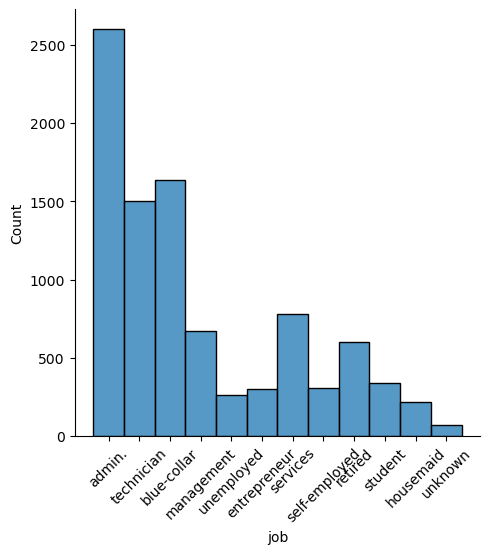

In [88]:
plot = sbn.displot(df['job'])
plot.set_xticklabels(rotation=45)

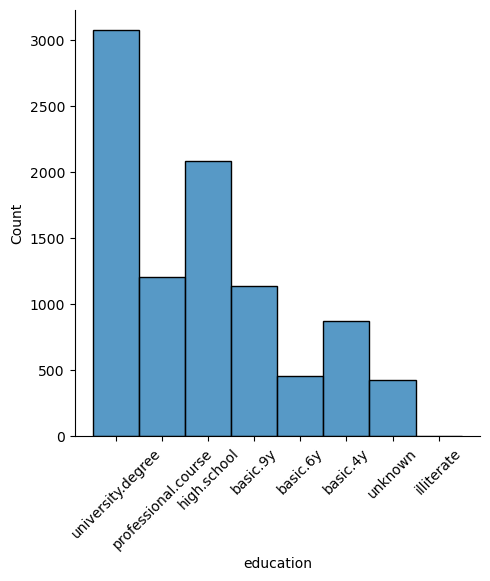

In [89]:
plot = sbn.displot(df['education'])
plot.set_xticklabels(rotation=45)

#### Encodons ces deux colonnes et testons de prédire `y` avec :

In [90]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
jobs_ord = oe.fit_transform(df[['job', 'education']])
jobs_ord

array([[0., 6.],
       [9., 5.],
       [9., 6.],
       ...,
       [9., 3.],
       [1., 0.],
       [9., 5.]])

In [91]:
clf = train_and_eval(jobs_ord, y)

	Precision: 0.553
	Recall: 0.655


#### Et avec un `OneHotEncoding` ?

In [92]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
jobs_onehot = ohe.fit_transform(df[['job', 'education']])
jobs_onehot

array([[1., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

#### Regardons le premier élément

In [93]:
jobs_ord[0]

array([0., 6.])

In [108]:
print(jobs_onehot[0])

[0. 6.]


In [107]:
jobs_onehot.shape

(9280, 20)

### Entrainons sur ces valeurs

In [95]:
clf = train_and_eval(jobs_onehot, y)

	Precision: 0.587
	Recall: 0.547


In [96]:
rf = train_and_eval_rf(jobs_onehot, y)

	Precision: 0.587
	Recall: 0.551


In [97]:
rf = train_and_eval_rf(jobs_ord, y)

	Precision: 0.588
	Recall: 0.554


On obtient de meilleurs résulats avec l'`OrdinalEncoding`. Et avec un `RandomForest` ?

#### Rajoutons maintenant la colonne `age`

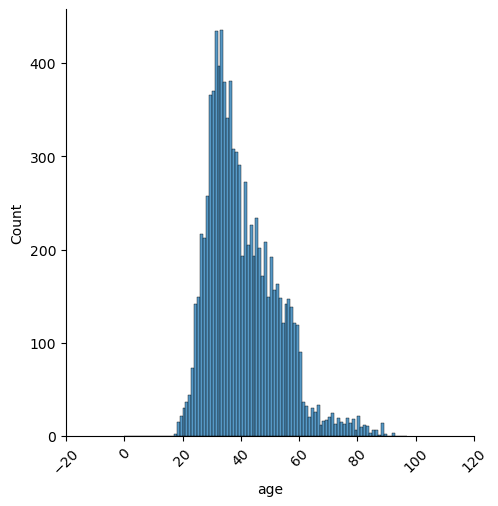

In [98]:
plot = sbn.displot(df["age"], bins=range(max(df.age)))
plot.set_xticklabels(rotation=45)

In [99]:
n_sample = df.shape[0]
train_data = np.empty((n_sample, jobs_ord.shape[1]+1)) # crée un nouveau ndarray ayant n_sample lignes et 3 colonnes (jobs_ord a 2 colonnes))
train_data[:,:-1] = jobs_ord # les deux premières colonnes correspondent à jobs_ord
train_data[:,-1] = df["age"] # la dernière est la colonne age

In [100]:
train_data

array([[ 0.,  6., 36.],
       [ 9.,  5., 41.],
       [ 9.,  6., 35.],
       ...,
       [ 9.,  3., 56.],
       [ 1.,  0., 56.],
       [ 9.,  5., 33.]])

In [101]:
clf = train_and_eval(train_data, y)

	Precision: 0.603
	Recall: 0.447


On observe une chute du `recall`
... mais une colonne a peut-<être biaisé le modele comme elle a une plage de valeur différente...

In [102]:
train_data[0]

array([ 0.,  6., 36.])

### Normalisation des données

 - On ne va pas utiliser un `OneHotEncoder` comme l'âge est une grandeur ordonnée
 - Attention : [`Normalizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Normalizer.html) ne fait pas ce que vous voulez, il normalise les échantillons (les lignes) au lieu de normaliser les _features_

In [116]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_data_norm = scaler.fit_transform(train_data)
train_data_norm

array([[0.        , 0.85714286, 0.2345679 ],
       [0.81818182, 0.71428571, 0.2962963 ],
       [0.81818182, 0.85714286, 0.22222222],
       ...,
       [0.81818182, 0.42857143, 0.48148148],
       [0.09090909, 0.        , 0.48148148],
       [0.81818182, 0.71428571, 0.19753086]])

In [117]:
train_data_norm[0]

array([0.        , 0.85714286, 0.2345679 ])

In [118]:
clf = train_and_eval(train_data_norm, y)

	Precision: 0.602
	Recall: 0.548


$\Rightarrow$ l'intérêt de la normalisation est évident ici

### Testons la standardisation, comme l'âge ressemble à une distribution normale

In [119]:
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
train_data_std = scaler_std.fit_transform(train_data)
train_data_std

array([[-1.05423689,  0.96827957, -0.36039821],
       [ 1.42576157,  0.49898232,  0.05389366],
       [ 1.42576157,  0.96827957, -0.44325658],
       ...,
       [ 1.42576157, -0.43961217,  1.29676925],
       [-0.77868151, -1.84750392,  1.29676925],
       [ 1.42576157,  0.49898232, -0.60897333]])

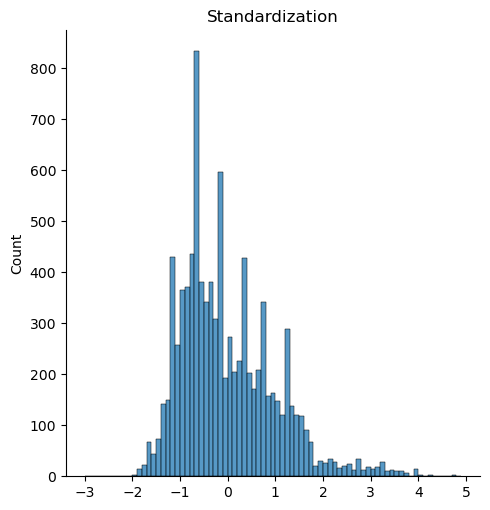

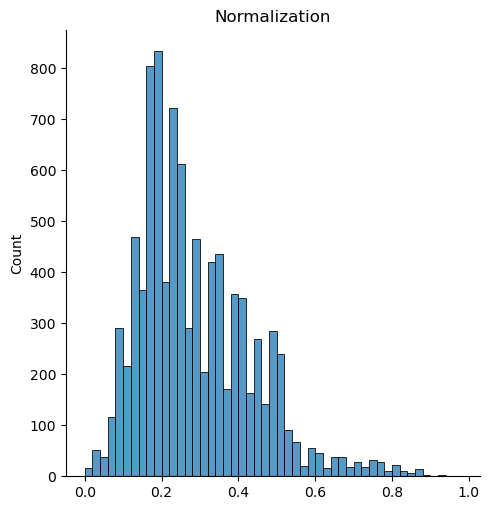

In [120]:
sbn.displot(train_data_std[:,-1],bins=np.arange(-3,5,0.1))
plt.title("Standardization")
sbn.displot(train_data_norm[:,-1],bins=np.arange(0,1,0.02))
_ = plt.title("Normalization")

In [121]:
clf = train_and_eval(train_data_std, y)

	Precision: 0.591
	Recall: 0.510


- la standardisation n'a rien apporté
- on remarque que la distribution n'est pas bien répartie autour de 0, testons des méthodes plus avancées de normalisation

In [123]:
from sklearn.preprocessing import RobustScaler
scaler_robust = RobustScaler()
train_data_robust = scaler_robust.fit_transform(train_data)
clf = train_and_eval(train_data_robust, y)

	Precision: 0.592
	Recall: 0.493


In [124]:
from sklearn.preprocessing import PowerTransformer
scaler_power = PowerTransformer()
train_data_power = scaler_power.fit_transform(train_data)
clf = train_and_eval(train_data_power, y)

	Precision: 0.601
	Recall: 0.477


In [125]:
from sklearn.preprocessing import QuantileTransformer
scaler_quantile = QuantileTransformer()
train_data_quantile = scaler_quantile.fit_transform(train_data)
clf = train_and_eval(train_data_quantile, y)

	Precision: 0.590
	Recall: 0.540


### Et si on avait eu du texte ?

In [126]:
mon_texte = "une belle chaine chaine de caractere comme notre jeu de donnée n'en avait pas"

In [127]:
from sklearn.feature_extraction.text import CountVectorizer
count_vec = CountVectorizer()
mon_texte_encode = count_vec.fit_transform([mon_texte]).toarray()
mon_texte_encode

array([[1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1]], dtype=int64)

In [128]:
mon_texte_encode

array([[1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1]], dtype=int64)

- Et pour savoir quelle feature encode quel mot ?

In [129]:
count_vec.get_feature_names_out()

array(['avait', 'belle', 'caractere', 'chaine', 'comme', 'de', 'donnée',
       'en', 'jeu', 'notre', 'pas', 'une'], dtype=object)

$\Rightarrow$ l'ordre n'est donc pas respecté

In [130]:
[(w, c) for w, c in zip(np.asarray(mon_texte_encode)[0], count_vec.get_feature_names_out())]

[(1, 'avait'),
 (1, 'belle'),
 (1, 'caractere'),
 (2, 'chaine'),
 (1, 'comme'),
 (2, 'de'),
 (1, 'donnée'),
 (1, 'en'),
 (1, 'jeu'),
 (1, 'notre'),
 (1, 'pas'),
 (1, 'une')]